In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../Week1/telco_churn_cleaned.csv')
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [2]:
(df['tenure'] * df['MonthlyCharges'] - df['TotalCharges']).describe()

count    7043.000000
mean       -0.152953
std        67.202778
min      -373.250000
25%       -28.500000
50%         0.000000
75%        28.600000
max       370.850000
dtype: float64

In [3]:
print(df['SeniorCitizen'].value_counts(normalize=True))
print(df['Contract'].value_counts(normalize=True))

SeniorCitizen
0    0.837853
1    0.162147
Name: proportion, dtype: float64
Contract
Month-to-month    0.550192
Two year          0.240664
One year          0.209144
Name: proportion, dtype: float64


In [4]:
print(df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack())

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


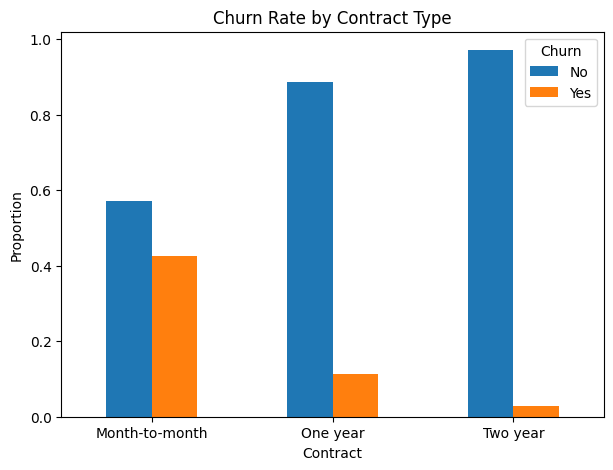

In [5]:
churn_by_contract = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
churn_by_contract.plot(kind='bar', stacked=False, figsize=(7,5))
plt.title('Churn Rate by Contract Type')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

In [6]:
df.groupby('Churn')['tenure'].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

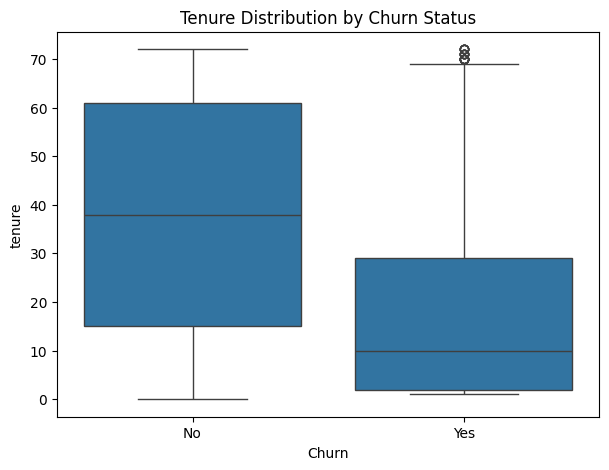

In [7]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure Distribution by Churn Status')
plt.show()

In [8]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

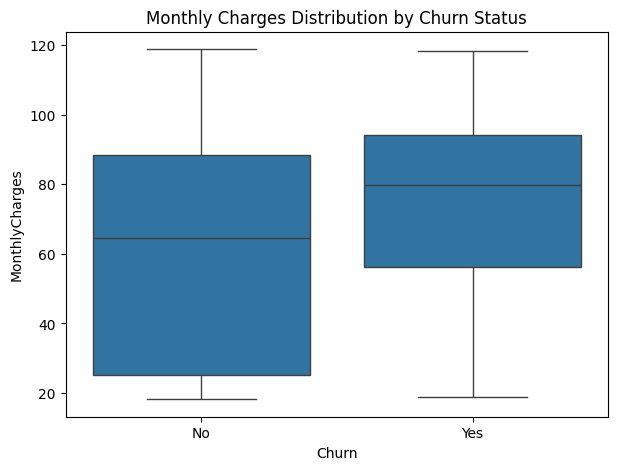

In [9]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges Distribution by Churn Status')
plt.show()

In [10]:
df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack()

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


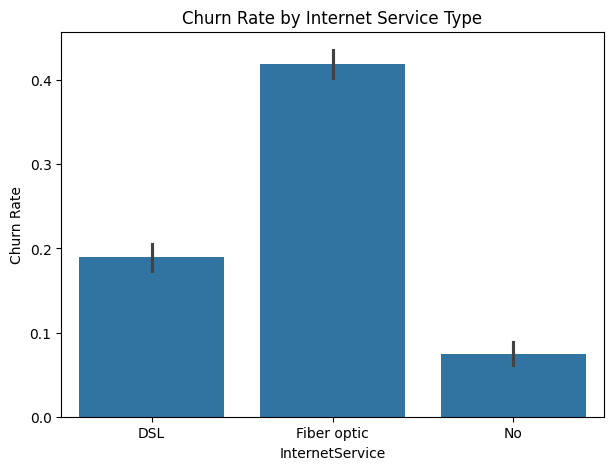

In [11]:
plt.figure(figsize=(7,5))
sns.barplot(data=df, x='InternetService', y=df['Churn'].map({'Yes':1,'No':0}))
plt.title('Churn Rate by Internet Service Type')
plt.ylabel('Churn Rate')
plt.show()

In [12]:
df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack()

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


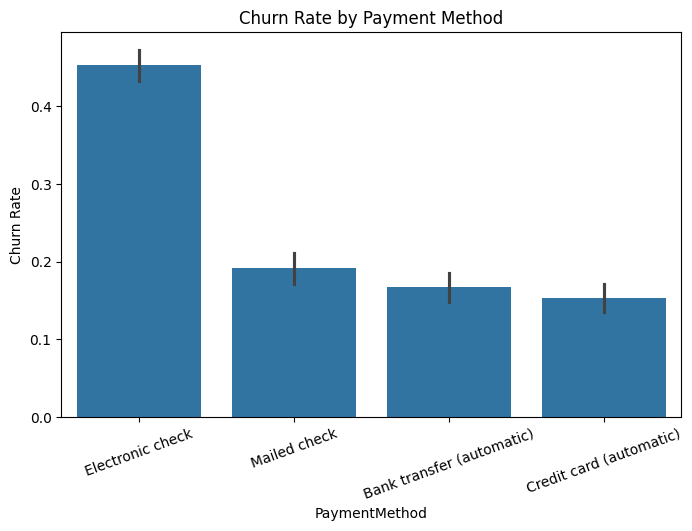

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='PaymentMethod', y=df['Churn'].map({'Yes':1,'No':0}))
plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate')
plt.xticks(rotation=20)
plt.show()

In [14]:
df.groupby('gender')['Churn'].value_counts(normalize=True).unstack()

Churn,No,Yes
gender,,
Female,0.730791,0.269209
Male,0.738397,0.261603


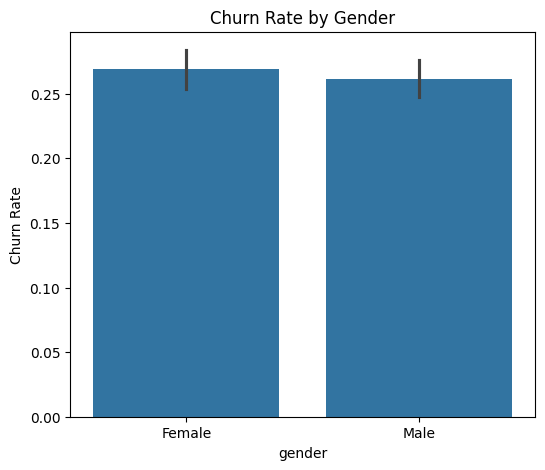

In [15]:
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='gender', y=df['Churn'].map({'Yes':1,'No':0}))
plt.title('Churn Rate by Gender')
plt.ylabel('Churn Rate')
plt.show()

In [16]:
df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack()

Churn,No,Yes
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


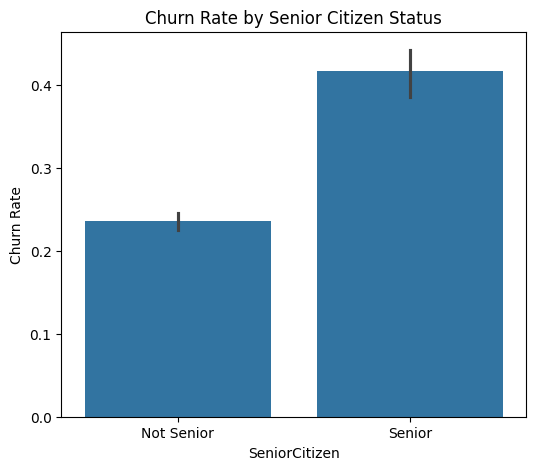

In [17]:
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='SeniorCitizen', y=df['Churn'].map({'Yes':1,'No':0}))
plt.title('Churn Rate by Senior Citizen Status')
plt.ylabel('Churn Rate')
plt.xticks([0,1], ['Not Senior', 'Senior'])
plt.show()

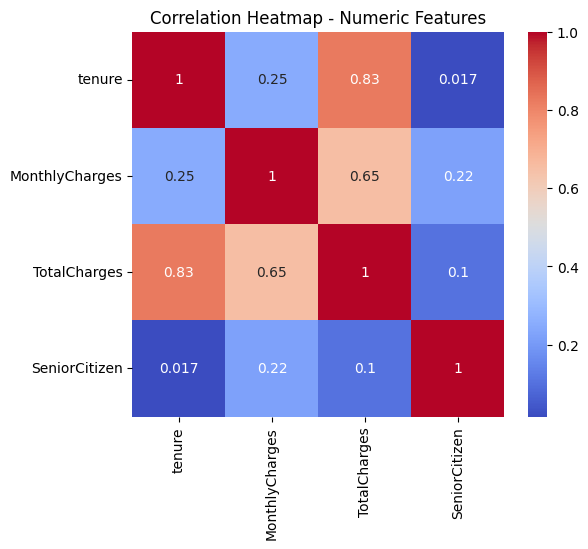

In [18]:
plt.figure(figsize=(6,5))
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges','SeniorCitizen']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap - Numeric Features')
plt.show()

In [19]:
df.groupby('gender')['Churn'].value_counts(normalize=True).unstack()


Churn,No,Yes
gender,,
Female,0.730791,0.269209
Male,0.738397,0.261603


In [20]:
df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack()

Churn,No,Yes
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


In [27]:
def tenure_group(t):
    if t <= 12:
        return '0-1 year'
    elif t <= 24:
        return '1-2 years'
    elif t <= 48:
        return '2-4 years'
    else:
        return '4+ years'


df['TenureGroup'] = df['tenure'].apply(tenure_group)
df['TenureGroup'].value_counts()

TenureGroup
4+ years     2239
0-1 year     2186
2-4 years    1594
1-2 years    1024
Name: count, dtype: int64

In [28]:
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['NumServices'] = df[service_cols].apply(lambda row: sum(row == 'Yes'), axis=1)
df['NumServices'].value_counts().sort_index()

NumServices
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64

In [29]:
df['SpendingTier'] = pd.qcut(df['MonthlyCharges'], q=3, labels=['Low', 'Medium', 'High'])
df['SpendingTier'].value_counts()

SpendingTier
Low       2351
High      2347
Medium    2345
Name: count, dtype: int64

In [30]:
df.groupby('TenureGroup')['Churn'].value_counts(normalize=True).unstack()

Churn,No,Yes
TenureGroup,,
0-1 year,0.525618,0.474382
1-2 years,0.712891,0.287109
2-4 years,0.796110,0.203890
4+ years,0.904868,0.095132


In [31]:
df.groupby('NumServices')['Churn'].value_counts(normalize=True).unstack()

Churn,No,Yes
NumServices,,
0,0.562500,0.437500
1,0.788948,0.211052
2,0.671717,0.328283
3,0.635233,0.364767
4,0.686551,0.313449
5,0.744493,0.255507
6,0.775148,0.224852
7,0.875949,0.124051
8,0.947115,0.052885


In [32]:
df.groupby('SpendingTier')['Churn'].value_counts(normalize=True).unstack()

C:\Users\glori\AppData\Local\Temp\ipykernel_15584\4146570163.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('SpendingTier')['Churn'].value_counts(normalize=True).unstack()


Churn,No,Yes
SpendingTier,,
Low,0.841344,0.158656
Medium,0.703198,0.296802
High,0.659139,0.340861


In [33]:
df_model = df.drop(columns=['customerID'])

In [34]:
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

In [35]:
df_model = pd.get_dummies(df_model, drop_first=True)
df_model.shape

(7043, 37)

In [36]:
from sklearn.preprocessing import StandardScaler

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices']
scaler = StandardScaler()
df_model[num_cols] = scaler.fit_transform(df_model[num_cols])

In [37]:
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']
print(X.shape, y.shape)
X.head()

(7043, 36) (7043,)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,NumServices,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_1-2 years,TenureGroup_2-4 years,TenureGroup_4+ years,SpendingTier_Medium,SpendingTier_High
0,0,-1.277445,-1.160323,-0.992611,-1.145997,False,True,False,False,True,...,False,True,False,True,False,False,False,False,False,False
1,0,0.066327,-0.259629,-0.172165,-0.176011,True,False,False,True,False,...,False,False,False,False,True,False,True,False,True,False
2,0,-1.236724,-0.362660,-0.958066,-0.176011,True,False,False,True,False,...,False,True,False,False,True,False,False,False,True,False
3,0,0.514251,-0.746535,-0.193672,-0.176011,True,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
4,0,-1.236724,0.197365,-0.938874,-1.145997,False,False,False,True,False,...,False,True,False,True,False,False,False,False,True,False
